In [1]:
import numpy as np
import tifffile as tiff
import os

In [3]:
apo_img_dir = '/home/nbahou/myimaging/apoDet/data/dataset2/windows_20x_2cat/apo'
no_apo_img_dir = '/home/nbahou/myimaging/apoDet/data/dataset2/windows_20x_2cat/no_apo'


input_dir = no_apo_img_dir
output_dir = '/home/nbahou/myimaging/apoDet/data/dataset2/windows_20x_reshaped/no_apo'




imgs = tiff.imread('/home/nbahou/myimaging/apoDet/data/dataset2/windows_20x_2cat/apo/apo_Exp05_WellA1_Site02_0.tif')

imgs.shape

(32, 32, 5)

In [7]:
img_reshaped = np.hstack([imgs[:,:,i] for i in range(imgs.shape[2])])

In [8]:
img_reshaped.shape

(32, 160)

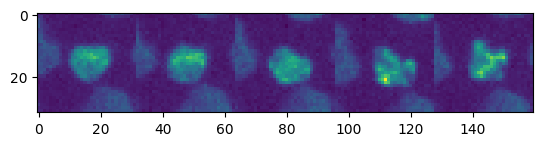

In [9]:
import matplotlib.pyplot as plt

plt.imshow(img_reshaped)
plt.show()

In [4]:
os.makedirs(output_dir, exist_ok=True)

counter_bad = 0
counter_good = 0

for filename in os.listdir(input_dir):
    img_path = os.path.join(input_dir, filename)
    img_array = tiff.imread(img_path)

    if img_array.shape != (32, 32, 5):
        counter_bad += 1
        print(f"Wrong shape! Shape: {img_array.shape}")
    else:
        img_reshaped = np.hstack([img_array[:,:,i] for i in range(img_array.shape[2])])
        counter_good += 1
        output_path = os.path.join(output_dir, filename)
        tiff.imwrite(output_path,img_reshaped)
print(f"Successful: {counter_good}")
print(f'Bad: {counter_bad}')

Successful: 258681
Bad: 0


In [ ]:
import os
import numpy as np
from PIL import Image

def rearrange_channels(input_dir, output_dir, horizontal=True):
    """
    Rearrange image channels either horizontally or vertically.
    
    Parameters:
    - input_dir: Directory containing 32x32x5 images
    - output_dir: Directory to save rearranged images
    - horizontal: If True, arrange channels horizontally; if False, vertically
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Process all images in the input directory
    for filename in os.listdir(input_dir):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp')):
            # Read the image
            img_path = os.path.join(input_dir, filename)
            img_array = np.load(img_path) if filename.lower().endswith('.npy') else np.array(Image.open(img_path))
            
            # Ensure the image is 32x32x5
            if img_array.shape != (32, 32, 5):
                print(f"Skipping {filename}: Incorrect shape {img_array.shape}")
                continue
            
            # Rearrange channels
            if horizontal:
                # Horizontal arrangement: 32x160
                rearranged = np.hstack(img_array[:, :, i] for i in range(5))
            else:
                # Vertical arrangement: 160x32
                rearranged = np.vstack(img_array[:, :, i] for i in range(5))
            
            # Convert to PIL Image and save
            output_path = os.path.join(output_dir, f'rearranged_{filename}')
            Image.fromarray(rearranged).save(output_path)
            print(f"Processed {filename}")

# Example usage
if __name__ == "__main__":
    input_directory = "path/to/your/input/images"
    output_directory = "path/to/your/output/images"
    
    # Rearrange horizontally (32x160)
    rearrange_channels(input_directory, output_directory, horizontal=True)
    
    # Uncomment the following line to rearrange vertically (160x32) instead
    # rearrange_channels(input_directory, output_directory, horizontal=False)

# Tips:
# 1. Replace input_directory and output_directory with your actual paths
# 2. Supports both image files (png, jpg, etc.) and NumPy .npy files
# 3. Uses NumPy's hstack/vstack for efficient channel rearrangement
# 4. Preserves original image files, creates new rearranged images